# E2 — a fresh NL→FOL faithfulness test set, stopped early by the budget: assembly and source verification (`data.py`)

This notebook is about **measuring the faithfulness of NL→FOL (autoformalization) outputs without a gold formula**.
**E2** is a *fresh confirmation set*. It does not overlap with the earlier meta-evaluation set **E**, and it is labelled by
E's code, frozen byte for byte. The generation run stopped early: the shared OpenRouter budget ran out after this artifact had spent $0.24. What exists:

* **550 pre-registered sentences** with gold FOL: 350 `L25` (long MALLS sentences, ≥25 words, ≥3 conditions), 100 `EXC` (exception sentences), 100 `DT` (ProverQA dev);
  520 of them are still `PENDING_GENERATION_BUDGET_STOP`.
* **A 30-sentence pilot**: 300 real candidates from 10 system slots (9 model families, temperature 0), plus 30 *gold-as-system* rows. The solver labelled them with
  E's labeller. With no panel votes, E's final rule gives 36 `ERROR`, 244 `UNRESOLVED`, 20 `UNPARSEABLE` and 0 `CORRECT`.
* **A partial panel drift check**: the 3 LLM judges (P1/P3/R1) were re-run on E's 77 synthetic gate items with a fresh cache.

The artifact's **`data.py`** is the last step of the pipeline. It takes the assembled groups, **checks every row against the original sources again**
(MALLS / ProverQA gold, the raw generation log, E's normaliser), adds the panel-drift rows, and writes
`full_data_out.json` / `mini_data_out.json` / `preview_data_out.json`.

**This demo** runs that script with as few changes as possible on `mini_demo_data.json`, a small bundle of its *inputs*: 5 pilot sentences with all 50 of their candidates,
10 pending sentences, the source records that match them, 12 calibration items with E's and E2's cached panel votes, and 10 track-H rows (6 replayed, 4 cut off).
No LLM or solver is called. The labels were already computed upstream, and `data.py` only checks and packages them.

## Setup
Install dependencies. `loguru` is not pre-installed on Colab. The core packages are installed at Colab's versions only when running outside Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

Imports: the original `data.py` import block, the imports of E's frozen normaliser (`re`, `unicodedata`), and the extra imports used for the tables and plots.

In [2]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

from loguru import logger

# used by E's frozen normaliser (src/normalise.py), inlined below
import re
import unicodedata

# notebook-only: tables and plots
import pandas as pd
import matplotlib.pyplot as plt

Data loading helper. It fetches `mini_demo_data.json` from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-4/dataset-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["about"])
print({d["dataset"]: len(d["examples"]) for d in data["assembled_E2"]["datasets"]},
      "| source records:", {k: len(v) for k, v in data["sources"].items()},
      "| generations:", len(data["generations"]), "| calibration items:", len(data["calibration_items"]),
      "| track-H rows:", len(data["trackh_panel_rows_E"]))

Self-contained subset of the inputs of E2's data.py (run_u75jRHUss0zo iter 4, gen_art_dataset_4). 5 pilot sentences with all their candidates, gold-as-system rows and generations; 10 pending sentences; their source records; 12 calibration items with E's and E2's cached panel votes; 10 track-H rows (6 replayed in E2, 4 cut off by the budget stop).
{'e2_candidates': 50, 'e2_gold_as_system': 5, 'e2_sentences': 15} | source records: {'yuan-yang__MALLS-v0__MALLS-v0.1-train.json': 11, 'yuan-yang__MALLS-v0__MALLS-v0.1-test.json': 0, 'opendatalab__ProverQA__dev_easy.json': 0, 'opendatalab__ProverQA__dev_medium.json': 2, 'opendatalab__ProverQA__dev_hard.json': 2} | generations: 52 | calibration items: 12 | track-H rows: 10


## Config
These are all the tunable values in one place. The `N_*` caps set how many rows of each assembled group go through the verification.
`None` means every row in the bundle (50 candidates / 5 gold-as-system / 15 sentences). The original run processed all rows:
300 / 30 / 550 plus 173 drift rows. `LIMIT`, `PREVIEW_TRUNC` and `MINI_N` are the original constants of `data.py`.

In [5]:
N_CANDIDATES = None      # rows of e2_candidates to verify (bundle has 50; original full run: 300)
N_GOLD_AS_SYSTEM = None  # rows of e2_gold_as_system (bundle has 5; original: 30)
N_SENTENCES = None       # rows of e2_sentences (bundle has 15; original: 550)
N_CALIB_ITEMS = None     # panel-drift synthetic gate items (bundle has 12; original: 77)
N_TRACKH_ROWS = None     # panel-drift track-H pairs (bundle has 10; original: 96)
LIMIT = 100 * 1000 * 1000  # max full_data_out.json size in bytes before a split is required (original)
PREVIEW_TRUNC = 200        # preview strings are cut to this many characters (original _trunc default)
MINI_N = 3                 # examples per group in mini_data_out.json (original)

## Constants and logging
This is the module-level setup from `data.py`. Output rows may hold only `input`, `output` and `metadata_*` keys, and none of the `FORBIDDEN` names.
`Q_PREFIX` is the fixed ProverQA question stem. It is removed so that the bare conclusion sentence can be matched.
The original script put paths on `ROOT / temp/datasets / work`. Here the inputs come from `data`, and the outputs go to the current directory.

In [6]:
ROOT = Path(".").resolve()
sys.setrecursionlimit(10000)

(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")
FORBIDDEN = {"split", "dataset", "context"}
Q_PREFIX = "Based on the above information, is the following statement true, false, or uncertain? "

## E's frozen output normaliser (`src/normalise.py`, inlined verbatim)
`data.py` imports `normalise` from E's code. The check is that `normalise(raw_output)` gives back the stored `candidate_fol` exactly. The normaliser
only maps surface syntax. It removes code fences and the `FOL:` prefix, keeps the first line, unwraps LaTeX, maps ASCII connectives and quantifiers to the
Unicode notation that the labeller parses, and folds diacritics in letters. It makes no semantic repairs.

In [7]:
LATEX = [
    (r"\\text\{([^{}]*)\}", r"\1"), (r"\\mathrm\{([^{}]*)\}", r"\1"), (r"\\operatorname\{([^{}]*)\}", r"\1"),
    (r"\\forall\s*", "∀"), (r"\\exists\s*", "∃"), (r"\\land\b|\\wedge\b", "∧"), (r"\\lor\b|\\vee\b", "∨"),
    (r"\\neg\b|\\lnot\b", "¬"), (r"\\leftrightarrow\b|\\iff\b|\\Leftrightarrow\b", "↔"),
    (r"\\rightarrow\b|\\to\b|\\Rightarrow\b|\\implies\b", "→"), (r"\\oplus\b", "⊕"),
    (r"\\\(|\\\)|\\\[|\\\]|\$", ""), (r"\\[,;!: ]", " "),
]
WORDOPS = [
    (r"\bforall\s+([a-z][a-z0-9]*)\s*[.:]?", r"∀\1 "), (r"\ball\s+([a-z])\s*\.", r"∀\1 "),
    (r"\bexists\s+([a-z][a-z0-9]*)\s*[.:]?", r"∃\1 "), (r"\bexist\s+([a-z])\s*\.", r"∃\1 "),
    (r"<->|<=>|⟷|⇔|≡", "↔"), (r"->|=>|⟶|⇒|⊃", "→"), (r"&&|&", "∧"), (r"\|\||\|", "∨"),
    (r"\bxor\b|⊻", "⊕"), (r"\bnot\s+", "¬"), (r"[~!]|¬", "¬"), (r"\band\b", "∧"), (r"\bor\b", "∨"),
]


def normalise(raw: str | None) -> tuple[str, list[str]]:
    applied: list[str] = []
    if raw is None:
        return "", ["none"]
    s = raw.strip()
    if "```" in s:
        m = re.search(r"```(?:[a-zA-Z]*)\n?(.*?)```", s, re.S)
        if m:
            s = m.group(1).strip()
            applied.append("code_fence")
    m = re.search(r"FOL\s*[:：]\s*(.+)", s)
    if m:
        s = m.group(1)
        applied.append("fol_prefix")
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    if len(lines) > 1:
        applied.append("first_line")
    s = lines[0] if lines else ""
    if "\\" in s or "$" in s:
        for a, b in LATEX:
            s = re.sub(a, b, s)
        applied.append("latex")
    s2 = s
    for a, b in WORDOPS:
        s2 = re.sub(a, b, s2)
    if s2 != s:
        applied.append("ascii_ops")
    s = s2.strip().strip("`").strip()
    s = re.sub(r"\s+", " ", s).rstrip(".")
    folded = "".join(_fold(ch) for ch in s)
    if folded != s:
        applied.append("ascii_fold")
        s = folded
    return s, applied


def _fold(ch: str) -> str:
    """Diacritic folding of non-ASCII LETTERS only (Sūduva -> Suduva); logic symbols are untouched."""
    if ch.isascii() or not unicodedata.category(ch).startswith("L"):
        return ch
    base = "".join(c for c in unicodedata.normalize("NFKD", ch) if not unicodedata.combining(c))
    return base if base.isascii() and base else "_"


print(normalise("```\nFOL: forall x (Bird(x) -> ~Swims(x)).\n```"))

('∀x (Bird(x) → ¬Swims(x))', ['code_fence', 'fol_prefix', 'ascii_ops'])


## Source index
`source_index()` maps **every source sentence to its gold FOL and source file**. MALLS contributes `NL → FOL`. Each ProverQA dev problem contributes its
`nl2fol` premise map and its conclusion (`question` minus `Q_PREFIX` → `conclusion_fol`). `setdefault` keeps the first occurrence.
Only change: the files are read from `data["sources"]` and not from `temp/datasets/`. The bundle holds only the records whose text belongs to the
demo's sentences, in their original order, so the first-occurrence winner is the same as in the full run.

In [8]:
def jl(rows: list[dict]) -> list[dict]:
    # original: read a .jsonl file line by line; here the lines are already parsed in the bundle
    return list(rows)


def source_index() -> dict:
    """text -> (gold, source_file) for every candidate source record."""
    idx = {}
    for f in ("yuan-yang__MALLS-v0__MALLS-v0.1-train.json", "yuan-yang__MALLS-v0__MALLS-v0.1-test.json"):
        for r in data["sources"][f]:
            idx.setdefault(r["NL"].strip(), (r["FOL"].strip(), f))
    for diff in ("easy", "medium", "hard"):
        f = f"opendatalab__ProverQA__dev_{diff}.json"
        for r in data["sources"][f]:
            for t, fo in r["nl2fol"].items():
                idx.setdefault(t.strip(), (fo.strip(), f))
            q = r["question"][len(Q_PREFIX):] if r["question"].startswith(Q_PREFIX) else r["question"]
            idx.setdefault(q.strip(), (r["conclusion_fol"].strip(), f))
    return idx

## Load the assembled groups and the generation log
This is the start of `main()`. `assembled_E2` is the output of `src_e2/assemble_e2.py`, which applied E's frozen final labelling rule. `gens` indexes the
generation log by `(sentence_id, slot, prompt_variant)`. **The last record wins**, so a retried generation replaces the earlier one.
`vcheck` counts the result of each source check. The config caps are applied here.

In [9]:
asm = data["assembled_E2"]
g = {x["dataset"]: x["examples"] for x in asm["datasets"]}
g["e2_candidates"] = g["e2_candidates"][:N_CANDIDATES]
g["e2_gold_as_system"] = g["e2_gold_as_system"][:N_GOLD_AS_SYSTEM]
g["e2_sentences"] = g["e2_sentences"][:N_SENTENCES]
idx = source_index()
gens = {}
for r in jl(data["generations"]):
    if r.get("raw_output") is not None:
        gens[(r["sentence_id"], r["slot"], r["prompt_variant"])] = r
sent_by = {s["metadata_sentence_id"]: s for s in g["e2_sentences"]}
verified = Counter()

def vcheck(tag: str, ok: bool) -> bool:
    verified[f"{tag}_{ok}"] += 1
    return ok

print(f"{len(idx)} source texts indexed, {len(gens)} generations, groups:", {k: len(v) for k, v in g.items()})

89 source texts indexed, 50 generations, groups: {'e2_candidates': 50, 'e2_gold_as_system': 5, 'e2_sentences': 15}


## Verify the real system candidates (`e2_candidates`)
A candidate row passes only if **all** of these hold:
1. its text is a source sentence;
2. a generation record exists for its (sentence, slot, variant);
3. the stored `metadata_raw_output` is byte-identical to that record's `raw_output`;
4. E's `normalise(raw)` reproduces the stored `candidate_fol`.

The `input` is rewritten so that it keeps only what a metric may see (text, candidate, system, prompt variant). The gold reference moves to `metadata_reference_fol`, which keeps
it hidden from anything that reads only `input`.

In [10]:
cands = []
for r in g["e2_candidates"]:
    inp = json.loads(r["input"])
    sid = r["metadata_sentence_id"]
    src = idx.get(inp["text"].strip())
    gen = gens.get((sid, r["metadata_slot"], r["metadata_prompt_variant"]))
    ok = bool(src) and gen is not None and gen["raw_output"] == r["metadata_raw_output"] and normalise(gen["raw_output"])[0] == inp["candidate_fol"]
    r = dict(r)
    r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                             "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
    r["metadata_reference_fol"] = inp["reference_fol"]
    r["metadata_model"] = r["metadata_generator_model_id"]
    r["metadata_model_returned"] = gen.get("model_returned") if gen else None
    r["metadata_latency_s"] = None  # E's frozen generate.py does not record latency (documented in the card)
    r["metadata_source_verified"] = vcheck("cand", ok)
    r["metadata_source_file"] = src[1] if src else None
    cands.append(r)
print(len(cands), "candidates;", dict(verified))

50 candidates; {'cand_True': 50}


## Verify the gold-as-system rows and the sentences
*Gold-as-system* rows feed the dataset's own gold formula back in as a "system" output. They check the labeller and the gold, and pass if the candidate
equals the source gold. *Sentence* rows pass if their text and original reference FOL match the source record. For the 520 pending sentences this is
the only check possible, because nothing was generated for them.

In [11]:
golds = []
for r in g["e2_gold_as_system"]:
    inp = json.loads(r["input"])
    src = idx.get(inp["text"].strip())
    ok = bool(src) and src[0] == inp["candidate_fol"].strip()
    r = dict(r)
    r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                             "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
    r["metadata_reference_fol"] = inp["reference_fol"]
    r["metadata_source_verified"] = vcheck("gold", ok)
    r["metadata_source_file"] = src[1] if src else None
    golds.append(r)
sents = []
for r in g["e2_sentences"]:
    inp = json.loads(r["input"])
    src = idx.get(inp["text"].strip())
    ok = bool(src) and src[0] == r["metadata_original_reference_fol"].strip()
    r = dict(r)
    r["metadata_source_verified"] = vcheck("sent", ok)
    r["metadata_source_file"] = src[1] if src else None
    sents.append(r)
print(len(golds), "gold-as-system,", len(sents), "sentences;", dict(verified))

5 gold-as-system, 15 sentences; {'cand_True': 50, 'gold_True': 5, 'sent_True': 15}


## Meaning-preserving controls
Controls are renamed copies of candidates that the solver confirmed `CORRECT`. They are supposed to be z3-equivalent under the inverse rename map, which makes them an
invariance test. The pilot has **0** `CORRECT` candidates, so `controls_E2.json` is empty and the group is dropped from the output, as in the original run.

In [12]:
ctrl = data["controls_E2"]["rows"] if data.get("controls_E2") else []
parents = {r["metadata_row_key"] for r in cands}
for r in ctrl:
    r["metadata_source_verified"] = vcheck("ctrl", r["metadata_control_parent_row_key"] in parents and bool(r["metadata_inverse_map_z3_equivalent"]))
print(len(ctrl), "control rows; report:", data["controls_E2"]["report"])

0 control rows; report: {'n_eligible_final_correct': 0, 'n_parents': 0, 'n_control_rows': 0, 'parents_by_stratum': {}, 'parents_by_tier': {}, 'log': {}}


## Panel drift rows (`drift_rows`, with `calib_votes` / `trackh_votes` from `src_e2/drift_report.py`)
This part checks whether the LLM judge panel still votes as it did for E. Each **synthetic gate item** (a gold formula or a perturbed variant with a known
label) becomes one row that holds E's stored votes and today's replayed votes. `calib_votes` reads a panel cache and keeps only parsed calibration calls
from members P1/P3/R1 made with the frozen prompt (`PROMPT_SHA1`). **Track-H** rows pair a real erroneous formula with its correction. The budget ran out after 16 of the 96 pairs
had been replayed, so the other pairs have `None` as their E2 votes. The bundle keeps 6 replayed pairs and 4 that were cut off.
Only change: the caches and row files come from `data` and are not read from disk. `PROMPT_SHA1` is the frozen panel prompt hash that `src/panel.py` computes.

In [13]:
PROMPT_SHA1 = data["panel_prompt_sha1"]  # = sha1(TEMPLATE + OPS_TXT) in E's src/panel.py
MEM = ["P1", "P3", "R1"]


def calib_votes(cache_rows: list) -> dict:
    out: dict = {}
    for r in cache_rows:  # original: for line in open(cache_path): r = json.loads(line)
        if r.get("parsed") and r["sentence_id"].startswith("calib|") and r["prompt_sha1"] == PROMPT_SHA1 and r["member"] in MEM:
            for cid, v in r["verdicts"].items():
                key = cid if cid != "REF" else "REF|" + r["sentence_id"]
                out.setdefault(key, {})[r["member"]] = bool(v["faithful"])
    return out


def trackh_votes(rows: list) -> dict:
    out = {}
    for r in rows:
        for m, v in r["votes"].items():
            if m in MEM:
                out.setdefault(f"H{r['id']}:orig", {})[m] = bool(v["orig_faithful"])
                out.setdefault(f"H{r['id']}:corr", {})[m] = bool(v["corr_faithful"])
    return out


def drift_rows() -> list[dict]:
    """One row per replayed drift item with E's stored votes and today's votes (None where the replay was cut off)."""
    items = data["calibration_items"][:N_CALIB_ITEMS]
    old_c = calib_votes(data["panel_cache_E"])
    new_c = calib_votes(data["panel_cache_E2"])
    rows = []
    for it in items:
        rows.append({"input": json.dumps({"text": it["text"], "candidate_fol": it["variant_fol"], "reference_fol": it["reference_fol"]}, ensure_ascii=False),
                     "output": it["gold"], "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "synthetic_gate",
                     "metadata_item": it["calib_id"], "metadata_variant_type": it["variant_type"],
                     "metadata_E_stored_votes": old_c.get(it["calib_id"]), "metadata_E2_replay_votes": new_c.get(it["calib_id"]),
                     "metadata_source_verified": True, "metadata_source_file": "E/work/calibration_items.json"})
    old_rows = data["trackh_panel_rows_E"][:N_TRACKH_ROWS]
    new_h = trackh_votes(data["trackh_panel_rows_E2"]) if data.get("trackh_panel_rows_E2") else {}
    old_h = trackh_votes(old_rows)
    for r in old_rows:
        rows.append({"input": json.dumps({"text": r["text"], "original_fol": r["orig"], "corrected_fol": r["corr"]}, ensure_ascii=False),
                     "output": "ORIGINAL_UNFAITHFUL__CORRECTED_FAITHFUL", "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "trackH_real_error_pairs",
                     "metadata_item": r["id"], "metadata_ambiguous_curated": r["ambiguous"],
                     "metadata_E_stored_votes": {"orig": old_h.get(f"H{r['id']}:orig"), "corr": old_h.get(f"H{r['id']}:corr")},
                     "metadata_E2_replay_votes": {"orig": new_h.get(f"H{r['id']}:orig"), "corr": new_h.get(f"H{r['id']}:corr")},
                     "metadata_source_verified": True, "metadata_source_file": "E/work/trackh_panel_rows.json"})
    return rows


drift = drift_rows()
print(len(drift), "drift rows")

22 drift rows


## Schema checks and output files
These are the end of `main()` and `_trunc`, unchanged. Every row must be `input`/`output` strings plus `metadata_*` keys. Groups with no rows are left out and
recorded in the metadata. The script writes `full_data_out.json`, the `mini` variant (first `MINI_N` rows per group) and the `preview` variant (every string cut to
`PREVIEW_TRUNC` characters). `workspace` is recorded relative to the current directory, so no server path is written.

In [14]:
def _trunc(o, n: int = PREVIEW_TRUNC):
    """Preview variant: every string truncated to n characters, recursively (aii-json preview convention)."""
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [_trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: _trunc(v, n) for k, v in o.items()}
    return o


groups = [("e2_candidates", cands), ("e2_gold_as_system", golds), ("e2_controls", ctrl), ("e2_sentences", sents), ("e2_panel_drift", drift)]
empty = [n for n, rows in groups if not rows]
for n, rows in groups:
    for r in rows:
        bad = [k for k in r if k not in ("input", "output") and not k.startswith("metadata_")] + [k for k in r if k in FORBIDDEN]
        assert not bad, (n, bad)
        assert isinstance(r["input"], str) and isinstance(r["output"], str)
out = {"metadata": {**asm["metadata"], "artifact": "E2 (run_u75jRHUss0zo iteration 4, gen_art_dataset_4, plan gen_plan_dataset_1_idx3)",
                    "workspace": ".", "empty_groups_omitted": empty, "source_verification": dict(verified),
                    "read_first": "dataset_card.md", "seal": "seal.json / candidates_E2_nolabels.jsonl / sealed/"},
       "datasets": [{"dataset": n, "examples": rows} for n, rows in groups if rows]}
txt = json.dumps(out, ensure_ascii=False)
assert len(txt.encode()) < LIMIT, "split needed (aii-file-size-limit)"
(ROOT / "full_data_out.json").write_text(txt)
mini = {"metadata": out["metadata"], "datasets": [{"dataset": x["dataset"], "examples": x["examples"][:MINI_N]} for x in out["datasets"]]}
(ROOT / "mini_data_out.json").write_text(json.dumps(mini, ensure_ascii=False, indent=1))
(ROOT / "preview_data_out.json").write_text(json.dumps(_trunc(mini), ensure_ascii=False, indent=1))
logger.info(f"full_data_out.json: {[(n, len(rows)) for n, rows in groups]}; empty omitted {empty}; verification {dict(verified)}; "
            f"{len(txt.encode()) / 1e6:.1f} MB")

11:48:47|INFO   |full_data_out.json: [('e2_candidates', 50), ('e2_gold_as_system', 5), ('e2_controls', 0), ('e2_sentences', 15), ('e2_panel_drift', 22)]; empty omitted ['e2_controls']; verification {'cand_True': 50, 'gold_True': 5, 'sent_True': 15}; 0.2 MB


## Results
The tables and plots summarise what the verified dataset contains:
* **Source verification**: how many rows of each group matched their sources. In the original run, all 880 did.
* **Candidate labels by stratum**: E's final label for each real candidate. With no panel votes the solver can only prove `ERROR` (a repair against the
  unaudited reference was found). Everything else is `UNRESOLVED` or `UNPARSEABLE`, and **no candidate is `CORRECT`**. This is why no metric can be confirmed on E2 in its current state.
* **Panel drift**: for each judge, how often the fresh replay agrees with E's stored vote on the synthetic gate items. The track-H summary counts how many pairs were replayed before the budget stop.

Source verification: {'cand_True': 50, 'gold_True': 5, 'sent_True': 15}
Groups written: [('e2_candidates', 50), ('e2_gold_as_system', 5), ('e2_sentences', 15), ('e2_panel_drift', 22)] | omitted (empty): ['e2_controls']

Candidate labels (rows = stratum):


label,ERROR,UNPARSEABLE,UNRESOLVED,All
fold,,,,
E2_DT,8,3,9,20
E2_EXC,6,0,4,10
E2_L25,0,10,10,20
All,14,13,23,50



Sample candidates (one per label):


,fold,system,label,tier,error_ops,candidate_fol
0,E2_DT,G1b,ERROR,A_unaudited_ref,"ADD,DROP",(EnvironmentallyNegligent(uriah) ⊕ CaresAbout(...
2,E2_DT,G2,UNRESOLVED,none,,(EnvironmentallyNegligent(uriah) ⊕ CaresAboutW...
10,E2_L25,G1b,UNPARSEABLE,-,,"∀x ∀y (ReflectsLight(x, y) ↔ (Surface(x) ∧ Cau..."



Sentences (status by stratum):


status,PENDING_GENERATION_BUDGET_STOP,UNAUDITED_MALLS_GPT4_GOLD,UNAUDITED_PROVERQA_GOLD
fold,,,
E2_DT,2,0,2
E2_EXC,3,1,0
E2_L25,5,2,0



Panel drift on synthetic gate items (E stored vs E2 replay):


,agree,n,agreement
P1,12.0,12.0,1.000000
P3,10.0,12.0,0.833333
R1,8.0,12.0,0.666667


Track-H rows: 10; replayed in E2 before the budget stop: 6; cut off (E2 votes None): 4


,pair,E_orig,E2_orig,E_corr,E2_corr
0,1,"{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}","{'P1': True, 'P3': True, 'R1': True}","{'P1': True, 'P3': True, 'R1': True}"
1,3,"{'P1': True, 'P3': True, 'R1': True}","{'P1': True, 'P3': True}","{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False}"
2,7,"{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}"
3,8,"{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}"
4,9,"{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}","{'P1': True, 'P3': True, 'R1': True}","{'P1': True, 'P3': True, 'R1': True}"
5,12,"{'P1': False, 'P3': False, 'R1': False}","{'P1': False, 'P3': False, 'R1': False}","{'P1': True, 'P3': True, 'R1': True}","{'P1': True, 'P3': True, 'R1': True}"
6,42,"{'P1': False, 'P3': True, 'R1': True}",None,"{'P1': False, 'P3': False, 'R1': False}",None
7,43,"{'P1': False, 'P3': False, 'R1': False}",None,"{'P1': True, 'P3': False, 'R1': True}",None
8,55,"{'P1': False, 'P3': False, 'R1': False}",None,"{'P1': True, 'P3': True, 'R1': False}",None
9,56,"{'P1': False, 'P3': False, 'R1': False}",None,"{'P1': False, 'P3': True, 'R1': True}",None


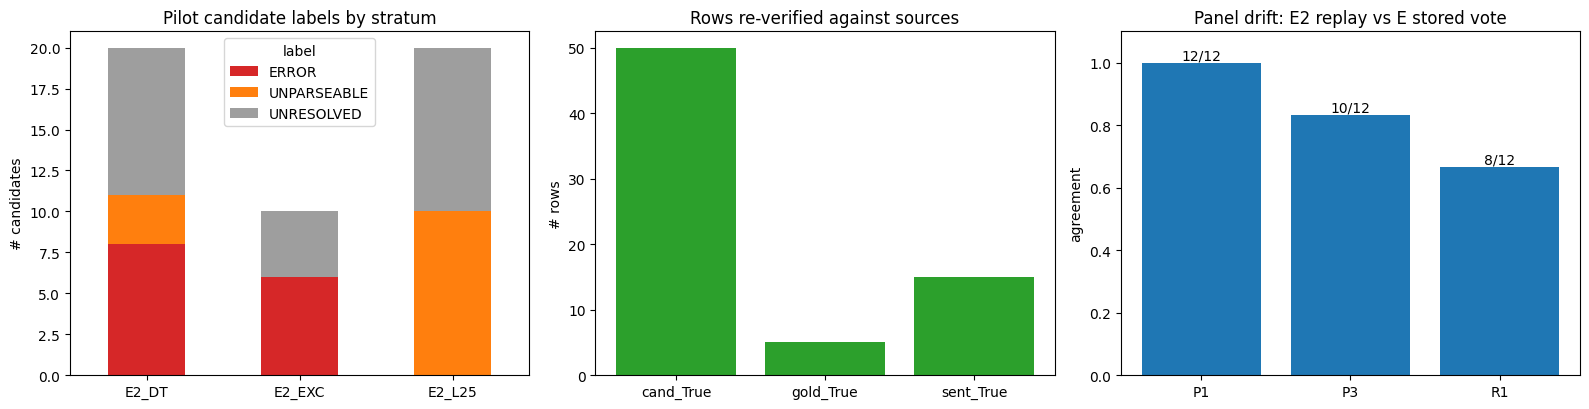

In [15]:
from IPython.display import display

print("Source verification:", dict(verified))
print("Groups written:", [(d["dataset"], len(d["examples"])) for d in out["datasets"]], "| omitted (empty):", empty)

cdf = pd.DataFrame([{"fold": r["metadata_fold"], "sentence": r["metadata_sentence_id"], "system": r["metadata_slot"],
                     "label": r["output"], "tier": r["metadata_label_tier"], "error_ops": ",".join(r["metadata_error_ops"] or []),
                     "candidate_fol": json.loads(r["input"])["candidate_fol"][:70]} for r in cands])
print("\nCandidate labels (rows = stratum):")
display(pd.crosstab(cdf["fold"], cdf["label"], margins=True))
print("\nSample candidates (one per label):")
display(cdf.groupby("label").head(1)[["fold", "system", "label", "tier", "error_ops", "candidate_fol"]])

sdf = pd.DataFrame([{"fold": r["metadata_fold"], "status": r["output"], "words": r["metadata_strata"].get("words"),
                     "n_conditions": r["metadata_strata"].get("n_conditions")} for r in sents])
print("\nSentences (status by stratum):")
display(pd.crosstab(sdf["fold"], sdf["status"]))

# panel drift: per-member agreement between E's stored vote and the E2 replay (synthetic gate items only)
agree = {m: [0, 0] for m in MEM}
for r in drift:
    if r["metadata_subset"] != "synthetic_gate":
        continue
    old, new = r["metadata_E_stored_votes"] or {}, r["metadata_E2_replay_votes"] or {}
    for m in MEM:
        if m in old and m in new:
            agree[m][0] += old[m] == new[m]
            agree[m][1] += 1
drift_tab = pd.DataFrame({m: {"agree": a, "n": n, "agreement": (a / n if n else float("nan"))} for m, (a, n) in agree.items()}).T
print("\nPanel drift on synthetic gate items (E stored vs E2 replay):")
display(drift_tab)
th = [r for r in drift if r["metadata_subset"] == "trackH_real_error_pairs"]
th_done = [r for r in th if r["metadata_E2_replay_votes"]["orig"]]
print(f"Track-H rows: {len(th)}; replayed in E2 before the budget stop: {len(th_done)}; cut off (E2 votes None): {len(th) - len(th_done)}")
display(pd.DataFrame([{"pair": r["metadata_item"], "E_orig": r["metadata_E_stored_votes"]["orig"], "E2_orig": r["metadata_E2_replay_votes"]["orig"],
                       "E_corr": r["metadata_E_stored_votes"]["corr"], "E2_corr": r["metadata_E2_replay_votes"]["corr"]} for r in th]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ct = pd.crosstab(cdf["fold"], cdf["label"])
colors = {"ERROR": "#d62728", "UNRESOLVED": "#9e9e9e", "UNPARSEABLE": "#ff7f0e", "CORRECT": "#2ca02c"}
ct.plot(kind="bar", stacked=True, ax=axes[0], color=[colors.get(c, "#1f77b4") for c in ct.columns], rot=0)
axes[0].set_title("Pilot candidate labels by stratum"); axes[0].set_ylabel("# candidates"); axes[0].set_xlabel("")
vc = pd.Series(dict(verified)).sort_index()
axes[1].bar(vc.index, vc.values, color=["#2ca02c" if k.endswith("True") else "#d62728" for k in vc.index])
axes[1].set_title("Rows re-verified against sources"); axes[1].set_ylabel("# rows")
axes[2].bar(drift_tab.index, drift_tab["agreement"].astype(float), color="#1f77b4")
for i, (m, row) in enumerate(drift_tab.iterrows()):
    axes[2].text(i, float(row["agreement"]) + 0.01, f"{int(row['agree'])}/{int(row['n'])}", ha="center")
axes[2].set_ylim(0, 1.1); axes[2].set_title("Panel drift: E2 replay vs E stored vote"); axes[2].set_ylabel("agreement")
plt.tight_layout(); plt.show()